PRÉTRAITEMENT MULTI-OMIQUE COMPLET
DATA_DIR: C:\Users\nidha\Desktop\xai_clinical_prediction\data\raw\brca_tcga
Existe: True

📥 Chargement des données brutes

[1/5] Chargement clinique...
✅ Clinical: (1097, 111)
Colonnes: ['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'MENOPAUSE_STATUS', 'RACE', 'ETHNICITY', 'HISTORY_OTHER_MALIGNANCY']

[2/5] Chargement mRNA RSEM...
✅ mRNA: (20531, 1102)
Transposé: (1100, 20531)
Après dédoublonnage: (1093, 20531)

[3/5] Chargement méthylation...
Colonnes méthylation: ['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01']...
Utilisation de 'Hugo_Symbol' comme index
✅ Methylation: (785, 16474)

[4/5] Chargement CNA...
✅ CNA: (1081, 24776)

[5/5] Chargement mutations...
✅ Mutations: (90490, 78)

Résumé chargement:
  - Clinical: (1097, 111)
  - mRNA: (1093, 20531)
  - Methylation: (785, 16474)
  - CNA: (1081, 24776)
  - Mutations: (90490, 78)

🎯 Créa

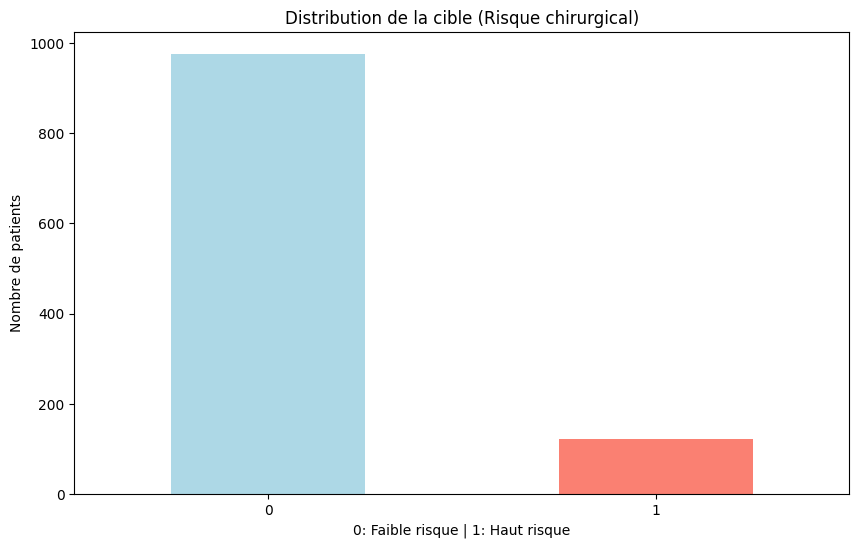


⚙️ Features cliniques
Features cliniques: (1097, 6)
Valeurs manquantes: 0

🧬 Features génomiques
mRNA features: (1093, 200)
Methylation features: (785, 100)
CNA features: (1081, 100)
Mutation features: (977, 100)

🔗 Fusion multi-omique
Échantillons communs: 657
Features combinées: (657, 506)


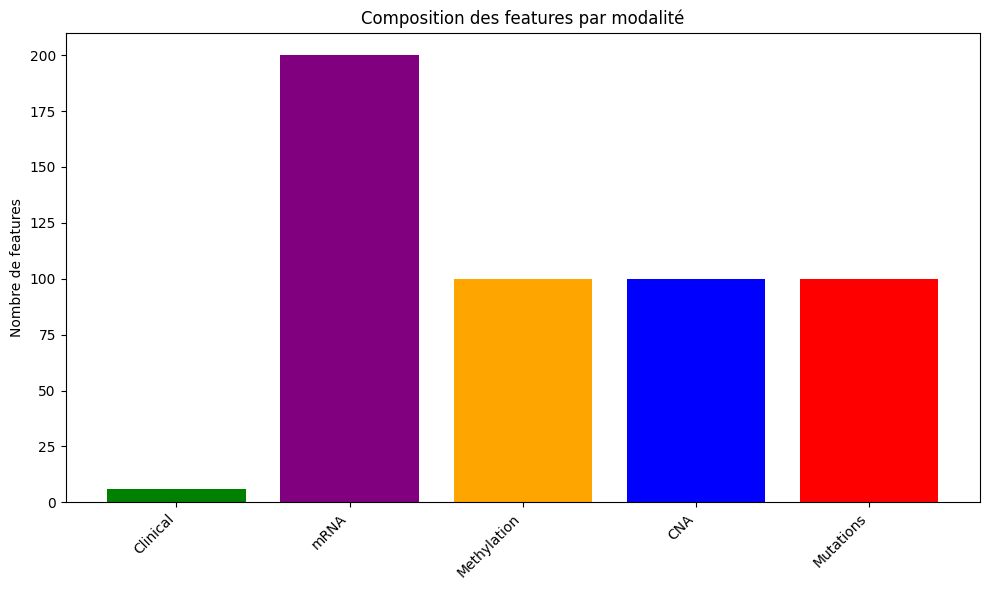


📊 Feature selection univariée
Features sélectionnées: 150


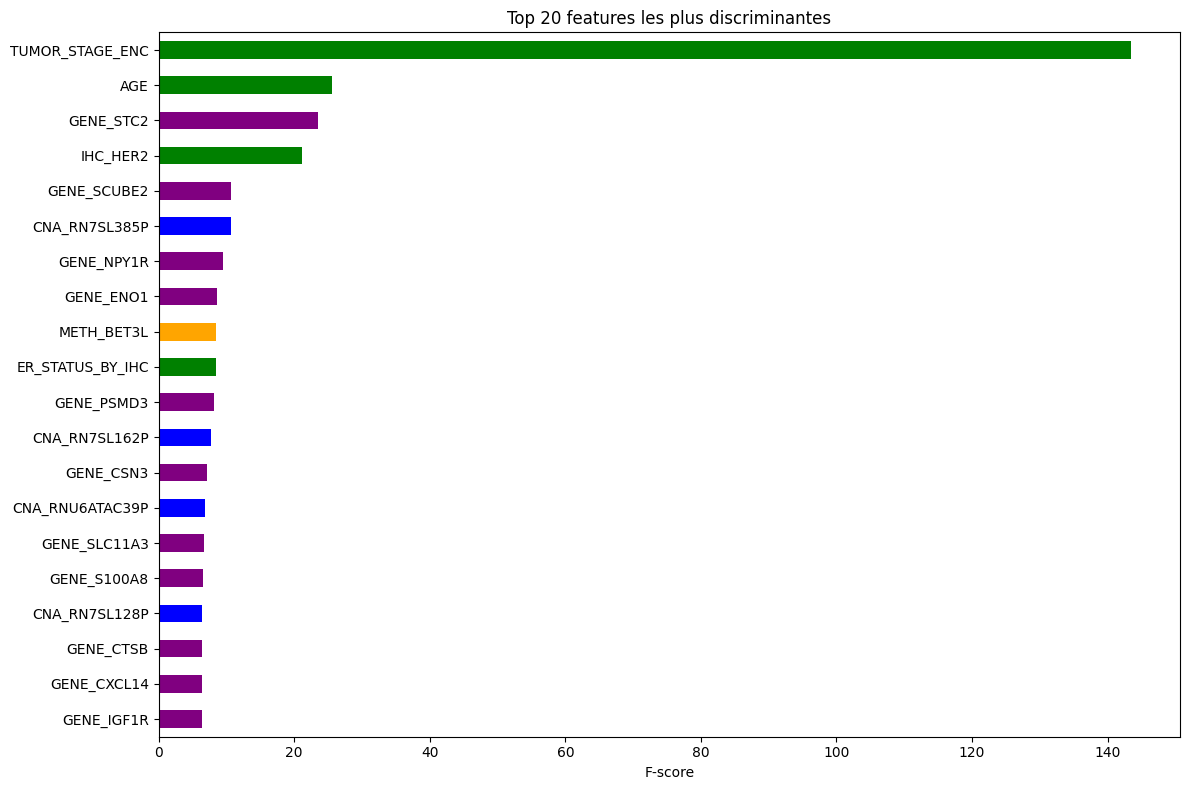


✂️ Split train/validation/test
Train: (420, 150), Val: (105, 150), Test: (132, 150)

💾 Sauvegarde

✅ PRÉTRAITEMENT TERMINÉ!
Données sauvegardées dans: C:\Users\nidha\Desktop\xai_clinical_prediction\data\processed
Figures sauvegardées dans: C:\Users\nidha\Desktop\xai_clinical_prediction\figures


In [14]:
# ============================================
# NOTEBOOK 02 : PRÉTRAITEMENT MULTI-OMIQUE
# ============================================

# Cellule 1 : Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
import joblib  # ← AJOUTE CETTE LIGNE
import warnings
warnings.filterwarnings('ignore')

# Chemins (Windows absolu)
PROJECT_ROOT = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction')
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'brca_tcga'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'

for d in [PROCESSED_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("="*70)
print("PRÉTRAITEMENT MULTI-OMIQUE COMPLET")
print("="*70)
print(f"DATA_DIR: {DATA_DIR}")
print(f"Existe: {DATA_DIR.exists()}")

# Cellule 2 : Chargement des données brutes
print("\n📥 Chargement des données brutes")

# Fonction pour trouver les fichiers .txt
def load_tsv_file(directory, basename):
    """Charge un fichier TSV avec extension .txt"""
    filepath = directory / f"{basename}.txt"
    if not filepath.exists():
        raise FileNotFoundError(f"Fichier non trouvé: {filepath}")
    
    # Détecter les lignes de commentaires (#)
    with open(filepath, 'r') as f:
        first_lines = [f.readline() for _ in range(5)]
    
    skip_rows = sum(1 for line in first_lines if line.startswith('#'))
    
    return pd.read_csv(filepath, sep='\t', skiprows=skip_rows)

# 1. Données cliniques
print("\n[1/5] Chargement clinique...")
clinical = load_tsv_file(DATA_DIR, 'data_clinical_patient')
print(f"✅ Clinical: {clinical.shape}")
print(f"Colonnes: {clinical.columns.tolist()[:10]}")

# Sauvegarder pour réutilisation
clinical.to_csv(PROCESSED_DIR / 'clinical_raw.csv', index=False)

# 2. mRNA RSEM
print("\n[2/5] Chargement mRNA RSEM...")
mrna = load_tsv_file(DATA_DIR, 'data_mrna_seq_v2_rsem')
print(f"✅ mRNA: {mrna.shape}")

# Transposer (gènes en colonnes, échantillons en lignes)
mrna_t = mrna.set_index('Hugo_Symbol').drop('Entrez_Gene_Id', axis=1, errors='ignore').T
print(f"Transposé: {mrna_t.shape}")

# Dédoublonner les IDs (garder premier)
mrna_t.index = [s[:12] for s in mrna_t.index]
mrna_t = mrna_t[~mrna_t.index.duplicated(keep='first')]
print(f"Après dédoublonnage: {mrna_t.shape}")

# 3. Méthylation HM450 (optionnel)
# REMPLACE la section méthylation par :

print("\n[3/5] Chargement méthylation...")
try:
    meth = load_tsv_file(DATA_DIR, 'data_methylation_hm450')
    print(f"Colonnes méthylation: {meth.columns.tolist()[:5]}...")
    
    # Trouver la colonne d'index (généralement première colonne ou 'Hybridization REF')
    possible_index_cols = ['Composite Element REF', 'Hybridization REF', 'ID_REF', 'Probe ID', 'IlmnID']
    index_col = None
    for col in possible_index_cols:
        if col in meth.columns:
            index_col = col
            break
    
    if index_col:
        meth_t = meth.set_index(index_col).T
    else:
        # Utiliser la première colonne comme index
        first_col = meth.columns[0]
        print(f"Utilisation de '{first_col}' comme index")
        meth_t = meth.set_index(first_col).T
    
    meth_t.index = [s[:12] for s in meth_t.index]
    meth_t = meth_t[~meth_t.index.duplicated(keep='first')]
    print(f"✅ Methylation: {meth_t.shape}")
    has_methylation = True
except Exception as e:
    print(f"⚠️ Méthylation non disponible: {e}")
    has_methylation = False
# 4. CNA (optionnel)
print("\n[4/5] Chargement CNA...")
try:
    cna = load_tsv_file(DATA_DIR, 'data_cna')
    cna_t = cna.set_index('Hugo_Symbol').T
    cna_t.index = [s[:12] for s in cna_t.index]
    cna_t = cna_t[~cna_t.index.duplicated(keep='first')]
    print(f"✅ CNA: {cna_t.shape}")
    has_cna = True
except FileNotFoundError:
    print("⚠️ CNA non disponible")
    has_cna = False

# 5. Mutations (optionnel)
print("\n[5/5] Chargement mutations...")
try:
    mut = load_tsv_file(DATA_DIR, 'data_mutations')
    print(f"✅ Mutations: {mut.shape}")
    has_mutations = True
except FileNotFoundError:
    print("⚠️ Mutations non disponible")
    has_mutations = False

print(f"\n{'='*70}")
print(f"Résumé chargement:")
print(f"  - Clinical: {clinical.shape}")
print(f"  - mRNA: {mrna_t.shape}")
print(f"  - Methylation: {meth_t.shape if has_methylation else 'N/A'}")
print(f"  - CNA: {cna_t.shape if has_cna else 'N/A'}")
print(f"  - Mutations: {mut.shape if has_mutations else 'N/A'}")

# Cellule 3 : Création de la cible (SANS data leakage)
print("\n🎯 Création de la cible (pré-opératoire uniquement)")

def create_target(clinical_df):
    """
    Cible basée UNIQUEMENT sur facteurs connus AVANT l'opération
    Évite le data leakage (ne PAS utiliser OS_STATUS/OS_MONTHS)
    """
    df = clinical_df.copy()
    
    # Score de risque combiné
    risk_factors = pd.DataFrame({
        'stage_advanced': df['AJCC_PATHOLOGIC_TUMOR_STAGE'].astype(str).str.contains('Stage III|Stage IV').fillna(False).astype(int) * 3,
        'grade_high': df['HISTOLOGICAL_DIAGNOSIS'].astype(str).str.contains('Grade 3|Grade 4').fillna(False).astype(int) * 2,
        'triple_negative': (
            (df['ER_STATUS_BY_IHC'] == 'Negative') & 
            (df['PR_STATUS_BY_IHC'] == 'Negative') & 
            (df['IHC_HER2'] == 'Negative')
        ).fillna(False).astype(int) * 3,
        'her2_positive': (df['IHC_HER2'] == 'Positive').fillna(False).astype(int) * 2,
        'age_risk': (pd.to_numeric(df['AGE'], errors='coerce') > 70).fillna(False).astype(int) * 1,
        'young_age': (pd.to_numeric(df['AGE'], errors='coerce') < 35).fillna(False).astype(int) * 1,
    })
    
    total_score = risk_factors.sum(axis=1)
    target = (total_score >= 4).astype(int)
    
    print(f"Distribution: {target.value_counts().to_dict()}")
    print(f"Mean risk score: {total_score.mean():.2f}")
    
    return target

y = create_target(clinical)

# Visualisation
plt.figure(figsize=(10, 6))
y.value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Distribution de la cible (Risque chirurgical)')
plt.xlabel('0: Faible risque | 1: Haut risque')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.savefig(FIGURES_DIR / '02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 4 : Préparation features cliniques
print("\n⚙️ Features cliniques")

# Sélection et nettoyage
clinical_features = ['AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'HISTOLOGICAL_DIAGNOSIS', 
                     'ER_STATUS_BY_IHC', 'PR_STATUS_BY_IHC', 'IHC_HER2']
X_clinical = clinical[clinical_features].copy()

# Nettoyage AGE
X_clinical['AGE'] = pd.to_numeric(X_clinical['AGE'], errors='coerce')
X_clinical['AGE'] = X_clinical['AGE'].fillna(X_clinical['AGE'].median())

# Encodage stade
stage_map = {
    'Stage I': 1, 'Stage IA': 1, 'Stage IB': 1,
    'Stage II': 2, 'Stage IIA': 2, 'Stage IIB': 2,
    'Stage III': 3, 'Stage IIIA': 3, 'Stage IIIB': 3, 'Stage IIIC': 3,
    'Stage IV': 4
}
X_clinical['TUMOR_STAGE_ENC'] = X_clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].map(stage_map).fillna(0)

# Encodage grade (depuis HISTOLOGICAL_DIAGNOSIS)
X_clinical['GRADE_ENC'] = X_clinical['HISTOLOGICAL_DIAGNOSIS'].astype(str).str.extract(r'Grade (\d)')[0].fillna(0).astype(int)

# Encodage statuts IHC
status_map = {'Positive': 1, 'Negative': 0, 'Indeterminate': 0.5, 'Equivocal': 0.5}
for col in ['ER_STATUS_BY_IHC', 'PR_STATUS_BY_IHC', 'IHC_HER2']:
    X_clinical[col] = X_clinical[col].map(status_map).fillna(0)

X_clinical = X_clinical[['AGE', 'TUMOR_STAGE_ENC', 'GRADE_ENC', 'ER_STATUS_BY_IHC', 'PR_STATUS_BY_IHC', 'IHC_HER2']]

print(f"Features cliniques: {X_clinical.shape}")
print(f"Valeurs manquantes: {X_clinical.isnull().sum().sum()}")

# Cellule 5 : Préparation features génomiques
print("\n🧬 Features génomiques")

# mRNA - Top gènes variables + log2
gene_vars = mrna_t.var().sort_values(ascending=False)
top_genes = gene_vars.head(200).index
X_mrna = np.log2(mrna_t[top_genes] + 1)
X_mrna.columns = [f'GENE_{c}' for c in X_mrna.columns]
print(f"mRNA features: {X_mrna.shape}")

# Méthylation (si disponible)
if has_methylation:
    meth_vars = meth_t.var().sort_values(ascending=False)
    top_meth = meth_vars.head(100).index
    X_meth = meth_t[top_meth].fillna(meth_t.median())
    X_meth.columns = [f'METH_{c}' for c in X_meth.columns]
    print(f"Methylation features: {X_meth.shape}")
else:
    X_meth = None

# CNA (si disponible)
if has_cna:
    cna_vars = cna_t.var().sort_values(ascending=False)
    top_cna = cna_vars.head(100).index
    X_cna = cna_t[top_cna]
    X_cna.columns = [f'CNA_{c}' for c in X_cna.columns]
    print(f"CNA features: {X_cna.shape}")
else:
    X_cna = None

# Mutations - matrice binaire (si disponible)
if has_mutations and 'Tumor_Sample_Barcode' in mut.columns and 'Hugo_Symbol' in mut.columns:
    mut_matrix = mut.pivot_table(
        index='Tumor_Sample_Barcode',
        columns='Hugo_Symbol',
        values='Variant_Classification',
        aggfunc='count',
        fill_value=0
    )
    mut_matrix.index = [s[:12] for s in mut_matrix.index]
    mut_matrix = mut_matrix[~mut_matrix.index.duplicated(keep='first')]
    
    # Top gènes mutés
    mut_counts = mut_matrix.sum(axis=0).sort_values(ascending=False)
    top_mut = mut_counts.head(100).index
    X_mut = mut_matrix[top_mut]
    X_mut.columns = [f'MUT_{c}' for c in X_mut.columns]
    print(f"Mutation features: {X_mut.shape}")
else:
    X_mut = None

# Cellule 6 : Alignement et fusion multi-omique
print("\n🔗 Fusion multi-omique")

# IDs patients (12 premiers caractères)
clinical_ids = clinical['PATIENT_ID'].str[:12].values

# Trouver intersection avec toutes les modalités
all_ids = [set(clinical_ids), set(mrna_t.index)]
if X_meth is not None: all_ids.append(set(X_meth.index))
if X_cna is not None: all_ids.append(set(X_cna.index))
if X_mut is not None: all_ids.append(set(X_mut.index))

common_ids = sorted(set.intersection(*all_ids))
print(f"Échantillons communs: {len(common_ids)}")

# Filtrer clinical
mask_clinical = [pid in common_ids for pid in clinical_ids]
X_clinical_filtered = X_clinical[mask_clinical].reset_index(drop=True)
y_filtered = y[mask_clinical].reset_index(drop=True)

# Filtrer et fusionner toutes les modalités
features_list = [X_clinical_filtered]

# mRNA
mrna_filtered = mrna_t.loc[common_ids].reset_index(drop=True)
X_mrna_filtered = np.log2(mrna_filtered[gene_vars.head(200).index] + 1)
X_mrna_filtered.columns = [f'GENE_{c}' for c in X_mrna_filtered.columns]
features_list.append(X_mrna_filtered)

# Méthylation
if X_meth is not None:
    meth_filtered = X_meth.loc[common_ids].reset_index(drop=True)
    features_list.append(meth_filtered)

# CNA
if X_cna is not None:
    cna_filtered = X_cna.loc[common_ids].reset_index(drop=True)
    features_list.append(cna_filtered)

# Mutations
if X_mut is not None:
    mut_filtered = X_mut.loc[common_ids].reset_index(drop=True)
    features_list.append(mut_filtered)

# Fusion finale
X_combined = pd.concat(features_list, axis=1)
print(f"Features combinées: {X_combined.shape}")

# Visualisation composition
feature_counts = {
    'Clinical': len(X_clinical_filtered.columns),
    'mRNA': len(X_mrna_filtered.columns),
}
if X_meth is not None: feature_counts['Methylation'] = len(meth_filtered.columns)
if X_cna is not None: feature_counts['CNA'] = len(cna_filtered.columns)
if X_mut is not None: feature_counts['Mutations'] = len(mut_filtered.columns)

plt.figure(figsize=(10, 6))
colors = ['green', 'purple', 'orange', 'blue', 'red']
plt.bar(feature_counts.keys(), feature_counts.values(), color=colors[:len(feature_counts)])
plt.title('Composition des features par modalité')
plt.ylabel('Nombre de features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_feature_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 7 : Feature selection
print("\n📊 Feature selection univariée")

selector = SelectKBest(f_classif, k=min(150, X_combined.shape[1]))
X_selected = selector.fit_transform(X_combined, y_filtered)
selected_features = X_combined.columns[selector.get_support()]

print(f"Features sélectionnées: {len(selected_features)}")

# Scores
scores = selector.scores_
feature_scores = pd.Series(scores, index=X_combined.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
top_20 = feature_scores.head(20)
colors = []
for f in top_20.index:
    if 'GENE_' in f: colors.append('purple')
    elif 'METH_' in f: colors.append('orange')
    elif 'CNA_' in f: colors.append('blue')
    elif 'MUT_' in f: colors.append('red')
    else: colors.append('green')

top_20.plot(kind='barh', color=colors)
plt.title('Top 20 features les plus discriminantes')
plt.xlabel('F-score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_feature_selection.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 8 : Split et scaling
print("\n✂️ Split train/validation/test")

X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Cellule 9 : Sauvegarde
print("\n💾 Sauvegarde")

np.save(PROCESSED_DIR / 'X_train.npy', X_train_scaled)
np.save(PROCESSED_DIR / 'X_val.npy', X_val_scaled)
np.save(PROCESSED_DIR / 'X_test.npy', X_test_scaled)
np.save(PROCESSED_DIR / 'y_train.npy', y_train)
np.save(PROCESSED_DIR / 'y_val.npy', y_val)
np.save(PROCESSED_DIR / 'y_test.npy', y_test)

pd.DataFrame(X_train_scaled, columns=selected_features).to_csv(
    PROCESSED_DIR / 'X_train.csv', index=False
)

joblib.dump(scaler, PROCESSED_DIR / 'scaler.joblib')
joblib.dump(selected_features, PROCESSED_DIR / 'selected_features.joblib')

print(f"\n{'='*70}")
print("✅ PRÉTRAITEMENT TERMINÉ!")
print(f"Données sauvegardées dans: {PROCESSED_DIR}")
print(f"Figures sauvegardées dans: {FIGURES_DIR}")
print(f"{'='*70}")